# 第19篇｜Matplotlib 基础：画布 / 坐标轴 / 图层

> 这是「数据分析从入门到精通」系列的第 19 篇，也是可视化阶段的开篇。数据处理能力到位了，下一步是"让数据开口说话"。Matplotlib 是 Python 可视化的基础，这篇先把画布、坐标轴、图层这几个核心概念搞清楚。

---

嗨，我是小荷～

第一阶段，我们把数据处理得干干净净。但"处理好的数据"和"让人一眼看懂的数据"之间，还差一样东西——**图表**。

数据可视化不是"加分项"，是**核心能力**。一张好图，胜过一页表格。这就是为什么萧何整理好账目之后，还要制作成"图示"呈给刘邦——数字让人理性，图像让人信服。

今天我们从 Matplotlib 的底层逻辑讲起，搞清楚"画布、坐标轴、图层"是什么关系，这是所有后续绘图的基础。

---

## 一、安装与导入

开始之前，先把环境准备好：


In [1]:
# 安装（如果还没有）
# pip install matplotlib

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd

# 中文显示配置
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False              # 负号正常显示


> 💡 macOS 用 `'Arial Unicode MS'`，Linux 用 `'WenQuanYi Micro Hei'`。

---

## 二、Matplotlib 的核心层级

Matplotlib 的绘图体系有三层：


In [ ]:
Figure（画布/窗口）
  └── Axes（坐标轴区域，一张 Figure 里可以有多个）
        ├── x轴、y轴
        ├── 标题
        ├── 图例
        └── 具体的图形对象（折线、柱状、散点...）


类比：
- **Figure** = 一张白纸（整个画框）
- **Axes** = 白纸上的一个坐标区域
- **Artist** = 坐标区域里画的具体内容

---

## 三、两种绘图方式

### 方式1：快速绘图（plt 接口）

plt 接口，来看具体怎么操作：


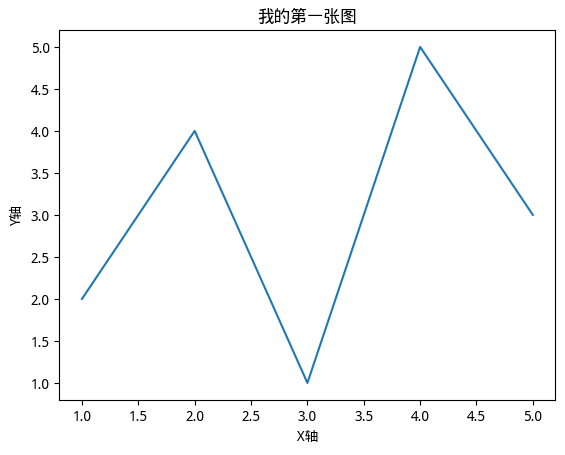

In [2]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 1, 5, 3]

plt.plot(x, y)
plt.title('我的第一张图')
plt.xlabel('X轴')
plt.ylabel('Y轴')
plt.show()


简单快捷，适合探索性分析。

---

### 方式2：面向对象（推荐）

推荐，来看具体怎么操作：


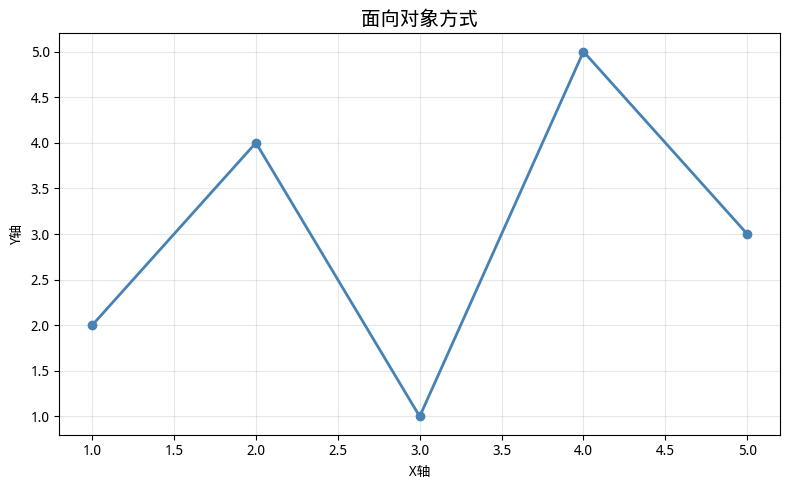

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))  # 创建 Figure 和 Axes

ax.plot(x, y, color='steelblue', linewidth=2, marker='o')
ax.set_title('面向对象方式', fontsize=14, fontweight='bold')
ax.set_xlabel('X轴')
ax.set_ylabel('Y轴')
ax.grid(True, alpha=0.3)  # 网格线，透明度 0.3

plt.tight_layout()  # 自动调整布局，防止文字被裁剪
plt.show()


面向对象方式更灵活，适合复杂图表，**推荐在实际工作中使用**。

---

## 四、Figure 与 Axes 详解

### 4.1 figsize 控制画布大小

来看看1 figsize 控制画布大小怎么实现：


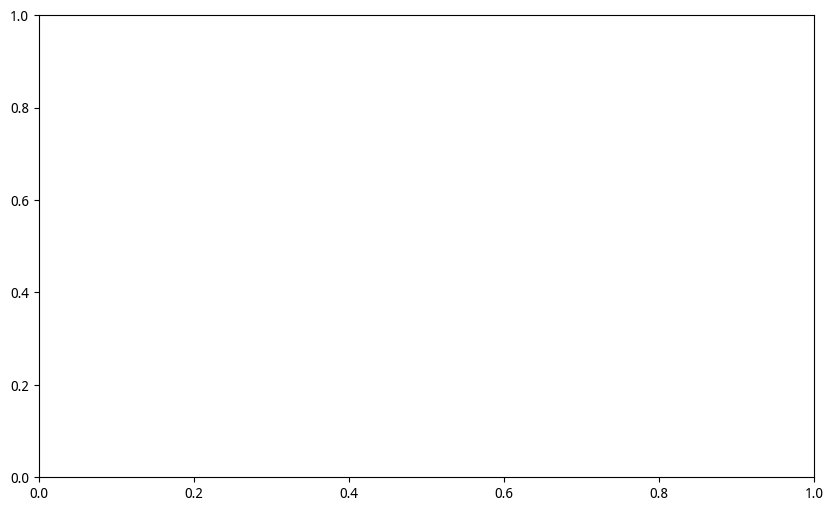

In [4]:
# figsize=(宽, 高)，单位是英寸
fig, ax = plt.subplots(figsize=(10, 6))   # 宽10英寸，高6英寸


常用尺寸：
- 普通单图：`(8, 5)` 或 `(10, 6)`
- PPT/报告用图：`(12, 7)`
- 正方形图：`(6, 6)`

---

### 4.2 坐标轴设置

来看看2 坐标轴设置怎么实现：


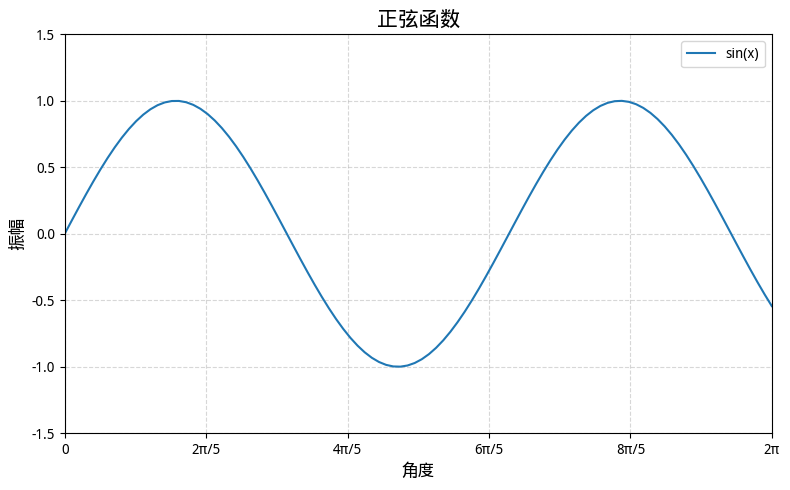

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), label='sin(x)')

# 标题和轴标签
ax.set_title('正弦函数', fontsize=15)
ax.set_xlabel('角度', fontsize=12)
ax.set_ylabel('振幅', fontsize=12)

# 坐标轴范围
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 1.5)

# 刻度
ax.set_xticks([0, 2, 4, 6, 8, 10])
ax.set_xticklabels(['0', '2π/5', '4π/5', '6π/5', '8π/5', '2π'])

# 图例
ax.legend(loc='upper right', fontsize=10)

# 网格
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


---

### 4.3 多子图：subplots 布局

来看看3 多子图：subplots 布局怎么实现：


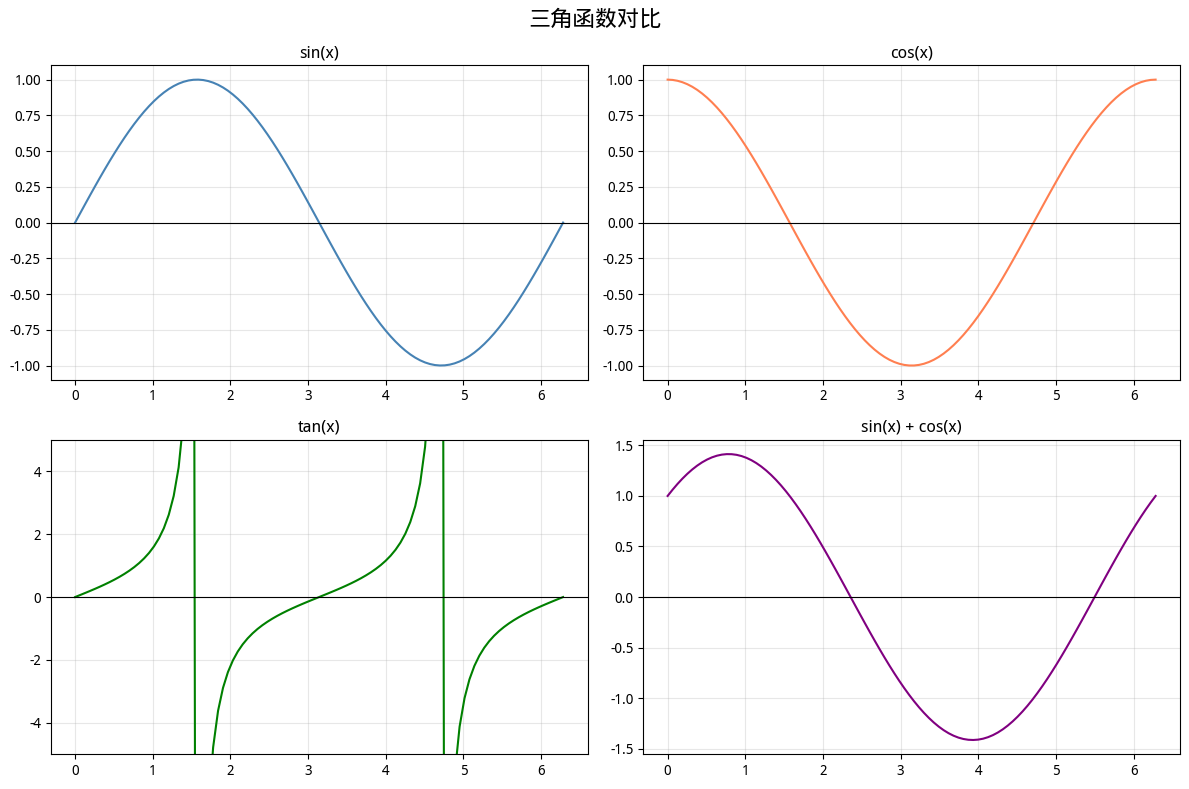

In [6]:
# 创建 2×2 的子图布局
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

x = np.linspace(0, 2 * np.pi, 100)

# 子图1
axes[0, 0].plot(x, np.sin(x), color='steelblue')
axes[0, 0].set_title('sin(x)')

# 子图2
axes[0, 1].plot(x, np.cos(x), color='coral')
axes[0, 1].set_title('cos(x)')

# 子图3
axes[1, 0].plot(x, np.tan(x), color='green')
axes[1, 0].set_title('tan(x)')
axes[1, 0].set_ylim(-5, 5)

# 子图4
axes[1, 1].plot(x, np.sin(x) + np.cos(x), color='purple')
axes[1, 1].set_title('sin(x) + cos(x)')

# 统一设置
for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linewidth=0.8)  # 添加 y=0 参考线

plt.suptitle('三角函数对比', fontsize=16, fontweight='bold')  # 整张图的大标题
plt.tight_layout()
plt.show()


---

## 五、常用样式设置

### 5.1 颜色

颜色是图表的第一印象，来看看怎么设置：


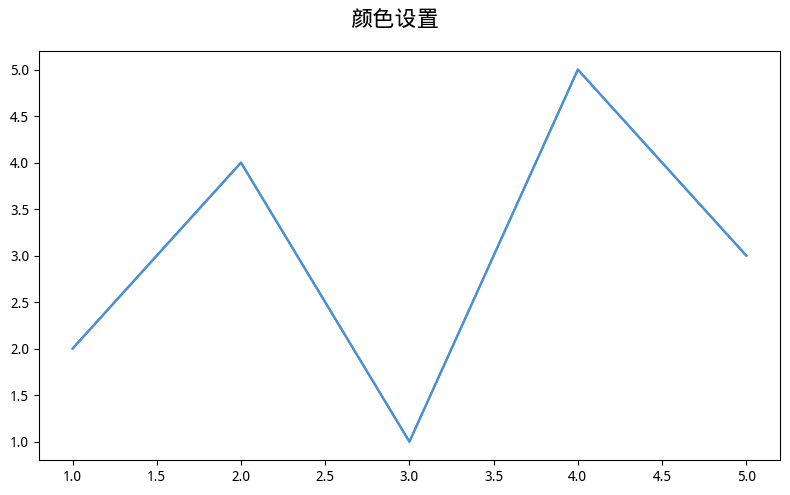

In [10]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 1, 5, 3]
# 颜色可以用：颜色名、十六进制、RGB元组
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y, color='steelblue')         # 颜色名
ax.plot(x, y, color='#FF6B6B')           # 十六进制
ax.plot(x, y, color=(0.2, 0.6, 0.9))    # RGB（0~1）

plt.suptitle('颜色设置', fontsize=16, fontweight='bold')  # 整张图的大标题
plt.tight_layout()
plt.show()

常用数据分析配色：
- `steelblue`（钢蓝，专业感）
- `coral`（珊瑚红，强调用）
- `#2ECC71`（绿色，正向数据）
- `#E74C3C`（红色，注意/负向）
- `#95A5A6`（灰色，次要信息）

### 5.2 线型与标记

来看看2 线型与标记怎么实现：


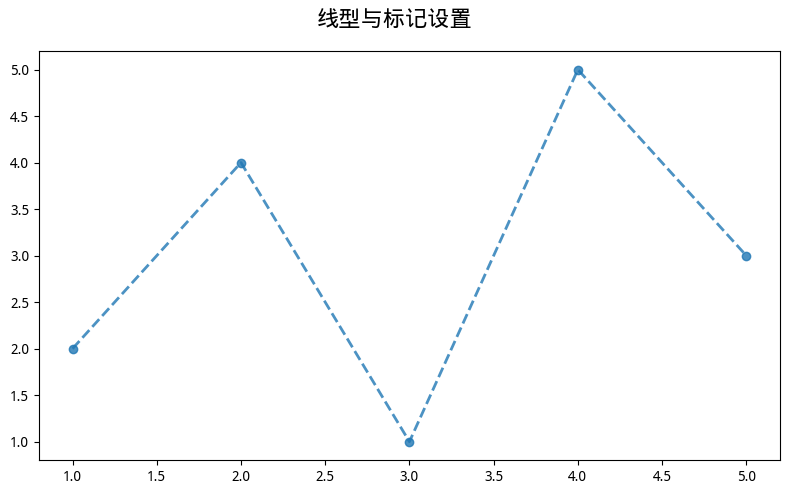

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y,
    linestyle='--',    # 线型：'-', '--', '-.', ':'
    linewidth=2,       # 线宽
    marker='o',        # 数据点标记：'o', 's', '^', 'D', '*'
    markersize=6,      # 标记大小
    alpha=0.8          # 透明度
)
plt.suptitle('线型与标记设置', fontsize=16, fontweight='bold')  # 整张图的大标题
plt.tight_layout()
plt.show()

### 5.3 使用内置样式

Matplotlib 内置了不少样式，一键切换风格：


In [ ]:
# 查看所有样式
print(plt.style.available)

# 使用样式（推荐的几个）
plt.style.use('seaborn-v0_8-whitegrid')   # 白色网格背景，最干净
plt.style.use('ggplot')                    # R 语言 ggplot 风格
plt.style.use('fivethirtyeight')           # 媒体数据新闻风格


---

## 六、图层叠加

Matplotlib 的"图层"思想：可以在同一个 Axes 上叠加多个图形对象：


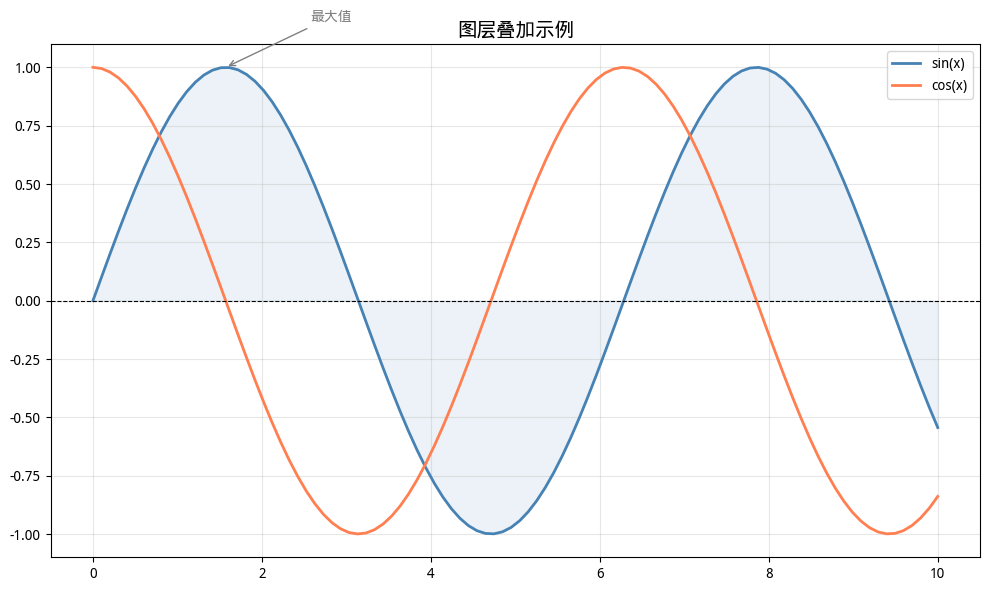

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.linspace(0, 10, 100)

# 叠加折线
ax.plot(x, np.sin(x), label='sin(x)', color='steelblue', linewidth=2)
ax.plot(x, np.cos(x), label='cos(x)', color='coral', linewidth=2)

# 叠加填充区域
ax.fill_between(x, np.sin(x), 0, alpha=0.1, color='steelblue')

# 叠加参考线
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

# 叠加注释
ax.annotate('最大值', xy=(np.pi/2, 1), xytext=(np.pi/2 + 1, 1.2),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=10, color='gray')

ax.set_title('图层叠加示例', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## 七、🔧 综合实战：制作第一张专业图表

学了一堆理论，来个完整的实战练练手——把前面学的知识点串起来：


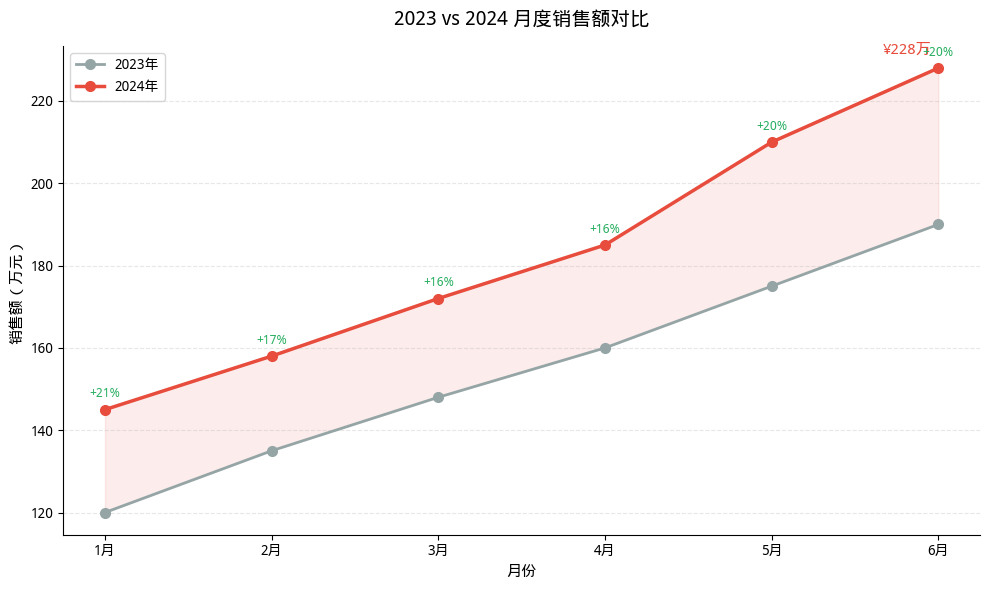

图表已保存为 sales_comparison.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

# 数据
months = ['1月', '2月', '3月', '4月', '5月', '6月']
sales_2023 = [120, 135, 148, 160, 175, 190]
sales_2024 = [145, 158, 172, 185, 210, 228]

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制两条折线
ax.plot(months, sales_2023, marker='o', linewidth=2, color='#95A5A6',
        label='2023年', markersize=7)
ax.plot(months, sales_2024, marker='o', linewidth=2.5, color='#E74C3C',
        label='2024年', markersize=7)

# 填充增长区域
ax.fill_between(months, sales_2023, sales_2024, alpha=0.1, color='#E74C3C')

# 标注最新数据点
ax.annotate(f'¥{sales_2024[-1]}万',
             xy=(months[-1], sales_2024[-1]),
             xytext=(-40, 10), textcoords='offset points',
             fontsize=11, color='#E74C3C', fontweight='bold')

# 样式设置
ax.set_title('2023 vs 2024 月度销售额对比', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('月份', fontsize=11)
ax.set_ylabel('销售额（万元）', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)     # 去掉顶部边框
ax.spines['right'].set_visible(False)   # 去掉右侧边框

# 标注同比增长率
for i, (v23, v24) in enumerate(zip(sales_2023, sales_2024)):
    growth = (v24 - v23) / v23 * 100
    ax.text(i, v24 + 3, f'+{growth:.0f}%', ha='center', fontsize=9, color='#27AE60')

plt.tight_layout()
plt.show()

---

## 八、📋 常用方法速查

| 功能 | 方法 |
|------|------|
| 创建画布+坐标轴 | `fig, ax = plt.subplots(figsize=(w,h))` |
| 折线图 | `ax.plot(x, y)` |
| 设置标题 | `ax.set_title('标题')` |
| 设置轴标签 | `ax.set_xlabel/ylabel('...')` |
| 设置轴范围 | `ax.set_xlim/ylim(min, max)` |
| 添加图例 | `ax.legend()` |
| 添加网格 | `ax.grid(True, alpha=0.3)` |
| 添加注释 | `ax.annotate('文字', xy=..., xytext=...)` |
| 保存图片 | `plt.savefig('file.png', dpi=150)` |
| 多子图 | `fig, axes = plt.subplots(rows, cols)` |

---

## 九、📝 小结

Matplotlib 的核心逻辑：
1. **Figure** 是白纸，`figsize` 控制大小
2. **Axes** 是坐标区域，绘图都在这里操作
3. **图层** 可以叠加——折线、散点、填充、注释都是独立图层
4. **面向对象写法**（`fig, ax = plt.subplots()`）比 `plt.xxx()` 更好维护

---

## 十、🏋️ 课后练习

1. 用 `subplots(1, 2)` 做两个子图，左图画 sin(x)，右图画 cos(x)，统一设置标题和网格。
2. 在你的折线图上用 `annotate` 标出最高点的值。
3. 尝试 `plt.style.use('seaborn-v0_8-whitegrid')`，感受不同风格的变化。

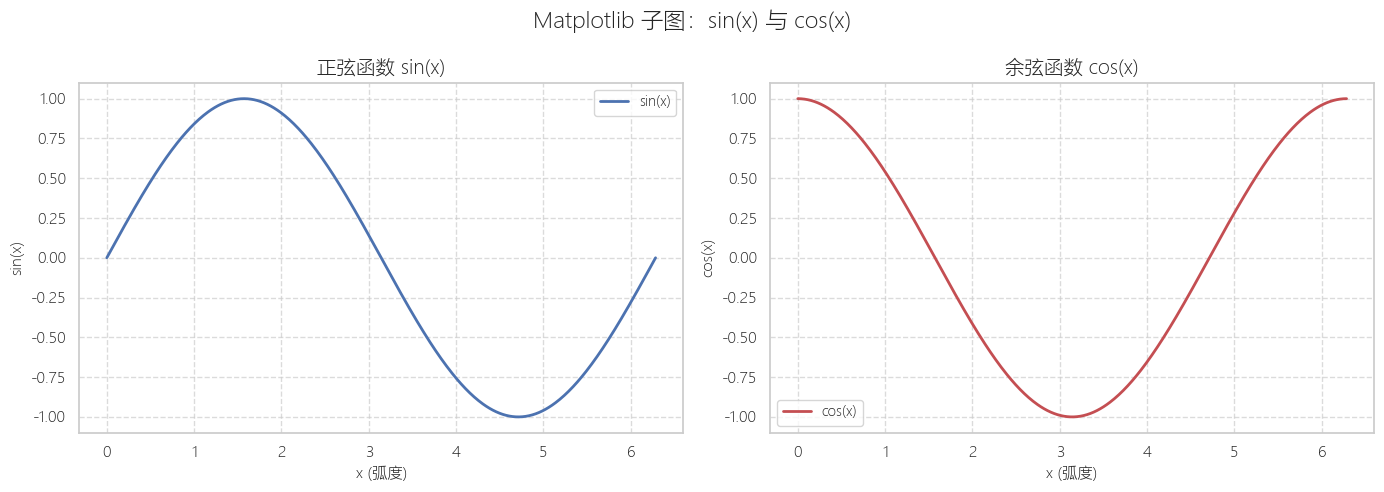

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

# seaborn 主题会覆盖字体设置，重新指定中文字体
# 设置绘图中文显示字体优先级：微软雅黑→黑体→数学专用DejaVu Sans
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans'] 
# 修复坐标轴负号显示为方框方块的bug
plt.rcParams['axes.unicode_minus'] = False
# 单独配置数学公式渲染字体，内置导数、梯度、积分等符号，不受中文字体限制
plt.rcParams['mathtext.fontset'] = 'dejavusans'


# ============================
# 练习1: subplots 画 sin(x) 和 cos(x)
# ============================

x = np.linspace(0, 2 * np.pi, 500)

# 原始 seaborn whitegrid 风格
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

# 左图: sin(x)
axes1[0].plot(x, np.sin(x), 'b-', linewidth=2, label='sin(x)')
axes1[0].set_title('正弦函数 sin(x)', fontsize=14, fontweight='bold')
axes1[0].set_xlabel('x (弧度)', fontsize=11)
axes1[0].set_ylabel('sin(x)', fontsize=11)
axes1[0].grid(True, linestyle='--', alpha=0.7)
axes1[0].legend(fontsize=10)

# 右图: cos(x)
axes1[1].plot(x, np.cos(x), 'r-', linewidth=2, label='cos(x)')
axes1[1].set_title('余弦函数 cos(x)', fontsize=14, fontweight='bold')
axes1[1].set_xlabel('x (弧度)', fontsize=11)
axes1[1].set_ylabel('cos(x)', fontsize=11)
axes1[1].grid(True, linestyle='--', alpha=0.7)
axes1[1].legend(fontsize=10)

fig1.suptitle('Matplotlib 子图：sin(x) 与 cos(x)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

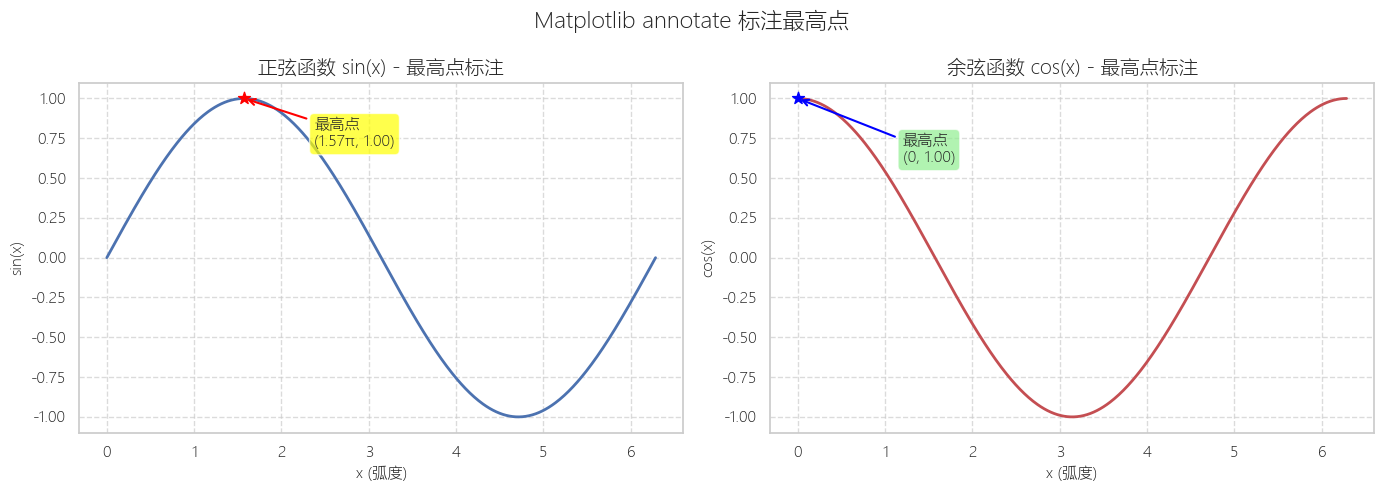

  - sin(x) 最高点: x = 1.5739 (约 0.50π), y = 1.0000
  - cos(x) 最高点: x = 0.0000 (约 0.00π), y = 1.0000


In [31]:
# ============================
# 练习2: annotate 标注最高点
# ============================

# sin(x) 最高点标注
sin_max_x = x[np.argmax(np.sin(x))]
sin_max_y = np.max(np.sin(x))

# cos(x) 最高点标注
cos_max_x = x[np.argmax(np.cos(x))]
cos_max_y = np.max(np.cos(x))

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

# 左图: sin(x) 标注最高点
axes2[0].plot(x, np.sin(x), 'b-', linewidth=2)
axes2[0].set_title('正弦函数 sin(x) - 最高点标注', fontsize=14, fontweight='bold')
axes2[0].set_xlabel('x (弧度)', fontsize=11)
axes2[0].set_ylabel('sin(x)', fontsize=11)
axes2[0].grid(True, linestyle='--', alpha=0.7)

# 添加最高点标注（带箭头）
axes2[0].annotate(f'最高点\n({sin_max_x:.2f}π, {sin_max_y:.2f})',
                  xy=(sin_max_x, sin_max_y),
                  xytext=(sin_max_x + 0.8, sin_max_y - 0.3),
                  fontsize=11,
                  arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
axes2[0].scatter([sin_max_x], [sin_max_y], color='red', s=80, zorder=5, marker='*')

# 右图: cos(x) 标注最高点
axes2[1].plot(x, np.cos(x), 'r-', linewidth=2)
axes2[1].set_title('余弦函数 cos(x) - 最高点标注', fontsize=14, fontweight='bold')
axes2[1].set_xlabel('x (弧度)', fontsize=11)
axes2[1].set_ylabel('cos(x)', fontsize=11)
axes2[1].grid(True, linestyle='--', alpha=0.7)

# 添加最高点标注（带箭头）
axes2[1].annotate(f'最高点\n(0, {cos_max_y:.2f})',
                  xy=(cos_max_x, cos_max_y),
                  xytext=(cos_max_x + 1.2, cos_max_y - 0.4),
                  fontsize=11,
                  arrowprops=dict(arrowstyle='->', color='blue', lw=1.5),
                  bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))
axes2[1].scatter([cos_max_x], [cos_max_y], color='blue', s=80, zorder=5, marker='*')

fig2.suptitle('Matplotlib annotate 标注最高点', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"  - sin(x) 最高点: x = {sin_max_x:.4f} (约 {sin_max_x/np.pi:.2f}π), y = {sin_max_y:.4f}")
print(f"  - cos(x) 最高点: x = {cos_max_x:.4f} (约 {cos_max_x/np.pi:.2f}π), y = {cos_max_y:.4f}")



练习3: 可用的 matplotlib 样式列表:
  1. Solarize_Light2
  2. _classic_test_patch
  3. _mpl-gallery
  4. _mpl-gallery-nogrid
  5. bmh
  6. classic
  7. dark_background
  8. fast
  9. fivethirtyeight
  10. ggplot
  11. grayscale
  12. petroff10
  13. seaborn-v0_8
  14. seaborn-v0_8-bright
  15. seaborn-v0_8-colorblind
  16. seaborn-v0_8-dark
  17. seaborn-v0_8-dark-palette
  18. seaborn-v0_8-darkgrid
  19. seaborn-v0_8-deep
  20. seaborn-v0_8-muted
  21. seaborn-v0_8-notebook
  22. seaborn-v0_8-paper
  23. seaborn-v0_8-pastel
  24. seaborn-v0_8-poster
  25. seaborn-v0_8-talk
  26. seaborn-v0_8-ticks
  27. seaborn-v0_8-white
  28. seaborn-v0_8-whitegrid
  29. tableau-colorblind10


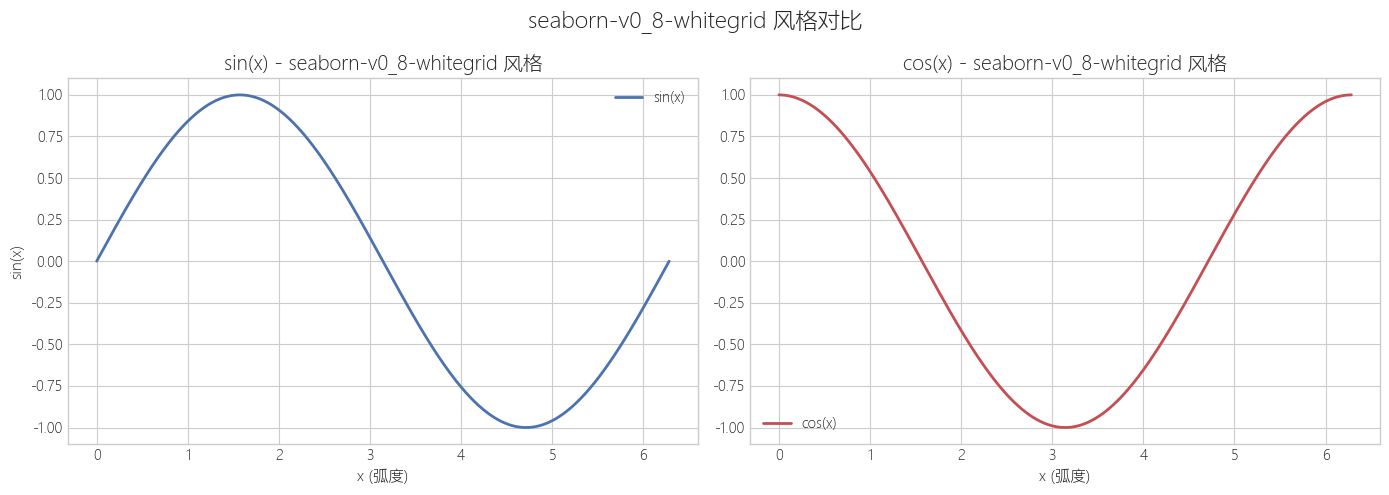

In [34]:
# ============================
# 练习3: 尝试不同风格
# ============================
# 查看可用的样式
print("\n" + "=" * 60)
print("练习3: 可用的 matplotlib 样式列表:")
print("=" * 60)
available_styles = plt.style.available
for i, style in enumerate(available_styles):
    print(f"  {i+1}. {style}")

# 演示 seaborn-v0_8-whitegrid 风格
plt.style.use('seaborn-v0_8-whitegrid')

# seaborn 主题会覆盖字体设置，重新指定中文字体
# 设置绘图中文显示字体优先级：微软雅黑→黑体→数学专用DejaVu Sans
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei','SimHei','DejaVu Sans'] 
# 修复坐标轴负号显示为方框方块的bug
plt.rcParams['axes.unicode_minus'] = False
# 单独配置数学公式渲染字体，内置导数、梯度、积分等符号，不受中文字体限制
plt.rcParams['mathtext.fontset'] = 'dejavusans'

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

axes3[0].plot(x, np.sin(x), 'b-', linewidth=2, label='sin(x)')
axes3[0].set_title('sin(x) - seaborn-v0_8-whitegrid 风格', fontsize=14, fontweight='bold')
axes3[0].set_xlabel('x (弧度)', fontsize=11)
axes3[0].set_ylabel('sin(x)', fontsize=11)
axes3[0].legend(fontsize=10)

axes3[1].plot(x, np.cos(x), 'r-', linewidth=2, label='cos(x)')
axes3[1].set_title('cos(x) - seaborn-v0_8-whitegrid 风格', fontsize=14, fontweight='bold')
axes3[1].set_xlabel('x (弧度)', fontsize=11)
axes3[1].legend(fontsize=10)

fig3.suptitle('seaborn-v0_8-whitegrid 风格对比', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# 恢复默认样式
plt.style.use('default')

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 20 篇：最常用的 5 种图表**
>
> 有了画布和坐标轴，下篇我们来系统学习最常用的 5 种图表：柱状图、折线图、饼图、散点图、面积图——每种图适合什么数据、怎么画得好看，全部覆盖。

---

*跟着小荷，数据分析路上不迷路～*